# Modern TIE (Boundary-Condition Optimized) - Notebook Prototype

This notebook implements a faithful modern TIE workflow aligned with the 2024 method you referenced:

1. Variable-intensity finite-difference TIE solve.
2. Boundary phase parameterized by low-frequency Fourier modes (8 coefficients).
3. Variational boundary optimization by matching re-propagated defocused intensities.

Dataset target in this notebook:
- Circular aperture diameter: **1 um**.
- Ground-truth phase: **quadratic bowl + two smooth ring features**.
- Defocus stack: **3 planes** (`-dz, 0, +dz`).

References:
- https://www.sciencedirect.com/science/article/pii/S0030402624005084
- https://arxiv.org/abs/2401.03744


## Notes

- Heavy computation is implemented with **JAX** where possible.
- Outer global optimization uses `scipy.optimize.direct` (as requested).
- This is notebook-only (no public API changes in `src/temgym_core`).


In [1]:
import os

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax.scipy.sparse.linalg import cg

from scipy import optimize

from temgym_core.utils import FresnelPropagator
from temgym_core.constants import energy2wavelength

jax.config.update("jax_enable_x64", True)

print("JAX version:", jax.__version__)
print("NumPy version:", np.__version__)


JAX version: 0.9.0
NumPy version: 2.3.5


In [2]:
# -----------------------------
# Configuration
# -----------------------------
N = 256
voltage = 200e3  # eV
wavelength = energy2wavelength(voltage)

aperture_diameter = 1e-6
aperture_radius = 0.5 * aperture_diameter

window_width = 4.0e-6
pixel_size = window_width / N

# Three-plane stack
base_dz = 20e-6

# Boundary parameterization
n_bc_modes = 8
bc_coeff_bound = 2.0  # radians

# Linear solve and regularization
intensity_floor = 1e-3
cg_tol = 1e-6
cg_maxiter = 4000
bc_l2 = 1e-4

# Optimization budgets
direct_maxfun_main = 320
direct_maxfun_sweep = 120
run_local_refine = True

print("wavelength [m] =", float(wavelength))
print("pixel_size [m] =", float(pixel_size))


wavelength [m] = 2.5079340317328468e-12
pixel_size [m] = 1.5625e-08


In [3]:
# -----------------------------
# Geometry and synthetic object
# -----------------------------
def make_xy_grid(n, dx):
    axis = (jnp.arange(n) - n // 2) * dx
    X, Y = jnp.meshgrid(axis, axis, indexing="xy")
    R = jnp.sqrt(X**2 + Y**2)
    return X, Y, R


def circular_mask(R, radius):
    return (R <= radius).astype(jnp.float64)


def ring_profile(R, r0, sigma, amp):
    return amp * jnp.exp(-0.5 * ((R - r0) / sigma) ** 2)


def make_phase_profile(R):
    # Quadratic + two ring-like radial structures
    # a2 chosen so phase is O(1 rad) at aperture edge
    a2 = 4.0e12  # rad / m^2

    ring1 = dict(r0=0.18e-6, sigma=0.025e-6, amp=+0.55)
    ring2 = dict(r0=0.34e-6, sigma=0.03e-6, amp=-0.40)

    phi = a2 * (R**2)
    phi = phi + ring_profile(R, **ring1)
    phi = phi + ring_profile(R, **ring2)

    params = {
        "a2": a2,
        "ring1": ring1,
        "ring2": ring2,
    }
    return phi, params


X, Y, R = make_xy_grid(N, pixel_size)
ap_mask = circular_mask(R, aperture_radius)

phi_true, gt_params = make_phase_profile(R)
U0_true = ap_mask * jnp.exp(1j * phi_true)


In [4]:
# -----------------------------
# Forward stack simulation + optional noise + preprocessing
# -----------------------------
def simulate_focus_stack(U0, L, lam, dz):
    U_minus = FresnelPropagator(U0, L, lam, -dz)
    U_plus = FresnelPropagator(U0, L, lam, +dz)

    I_minus = jnp.abs(U_minus) ** 2
    I0 = jnp.abs(U0) ** 2
    I_plus = jnp.abs(U_plus) ** 2
    return I_minus, I0, I_plus


def add_noise_stack(I_minus, I0, I_plus, *, poisson_counts=None, read_noise_sigma=0.0, key_seed=0):
    if poisson_counts is None and read_noise_sigma <= 0.0:
        return I_minus, I0, I_plus

    key = jax.random.PRNGKey(key_seed)
    keys = jax.random.split(key, 9)

    def noisy_plane(I, k0, k1, k2):
        I = jnp.clip(I, 0.0, None)
        Imax = jnp.maximum(jnp.max(I), 1e-12)

        out = I
        if poisson_counts is not None:
            lam = I / Imax * poisson_counts
            counts = jax.random.poisson(k0, lam=lam)
            out = counts / poisson_counts * Imax

        if read_noise_sigma > 0.0:
            sigma_abs = read_noise_sigma * Imax
            out = out + sigma_abs * jax.random.normal(k1, shape=I.shape)

        out = jnp.clip(out, 0.0, None)
        return out

    return (
        noisy_plane(I_minus, keys[0], keys[1], keys[2]),
        noisy_plane(I0, keys[3], keys[4], keys[5]),
        noisy_plane(I_plus, keys[6], keys[7], keys[8]),
    )


def register_stack_identity(I_minus, I0, I_plus):
    # Placeholder for future affine registration.
    return I_minus, I0, I_plus


def normalize_stack(I_minus, I0, I_plus):
    s = jnp.maximum(jnp.max(I0), 1e-12)
    return I_minus / s, I0 / s, I_plus / s


L_window = window_width

I_minus_clean, I0_clean, I_plus_clean = simulate_focus_stack(U0_true, L_window, wavelength, base_dz)
I_minus_clean, I0_clean, I_plus_clean = register_stack_identity(I_minus_clean, I0_clean, I_plus_clean)
I_minus_clean, I0_clean, I_plus_clean = normalize_stack(I_minus_clean, I0_clean, I_plus_clean)


In [5]:
# -----------------------------
# Variable-intensity finite-difference TIE model
# -----------------------------
def build_boundary_order(n):
    # Clockwise perimeter ordering without duplicated corners
    top_x = jnp.arange(n)
    top_y = jnp.zeros((n,), dtype=jnp.int32)

    right_y = jnp.arange(1, n - 1)
    right_x = jnp.full((n - 2,), n - 1, dtype=jnp.int32)

    bot_x = jnp.arange(n - 1, -1, -1)
    bot_y = jnp.full((n,), n - 1, dtype=jnp.int32)

    left_y = jnp.arange(n - 2, 0, -1)
    left_x = jnp.zeros((n - 2,), dtype=jnp.int32)

    bx = jnp.concatenate([top_x, right_x, bot_x, left_x], axis=0)
    by = jnp.concatenate([top_y, right_y, bot_y, left_y], axis=0)
    return by, bx


BY, BX = build_boundary_order(N)
N_B = BY.shape[0]


def build_boundary_basis(n_boundary, n_modes=8):
    # 8 modes = cos/sin pairs for harmonics m=1..4
    t = jnp.arange(n_boundary) / n_boundary
    basis_cols = []
    for m in range(1, n_modes // 2 + 1):
        basis_cols.append(jnp.cos(2.0 * jnp.pi * m * t))
        basis_cols.append(jnp.sin(2.0 * jnp.pi * m * t))
    B = jnp.stack(basis_cols[:n_modes], axis=1)
    # normalize columns for numerically similar coefficient scales
    B = B / jnp.maximum(jnp.linalg.norm(B, axis=0, keepdims=True), 1e-12)
    return B


B_BC = build_boundary_basis(N_B, n_bc_modes)


def coeffs_to_boundary_phase(coeffs, basis=B_BC, by=BY, bx=BX, n=N):
    vec = basis @ coeffs
    phi_b = jnp.zeros((n, n), dtype=jnp.float64)
    phi_b = phi_b.at[by, bx].set(vec)
    return phi_b


def div_I_grad(phi, I0, dx):
    # flux-form divergence of I * grad(phi) on interior nodes
    c = phi[1:-1, 1:-1]
    e = phi[1:-1, 2:]
    w = phi[1:-1, :-2]
    s = phi[2:, 1:-1]
    n = phi[:-2, 1:-1]

    I_c = I0[1:-1, 1:-1]
    I_e = 0.5 * (I_c + I0[1:-1, 2:])
    I_w = 0.5 * (I_c + I0[1:-1, :-2])
    I_s = 0.5 * (I_c + I0[2:, 1:-1])
    I_n = 0.5 * (I_c + I0[:-2, 1:-1])

    out = (
        I_e * (e - c)
        - I_w * (c - w)
        + I_s * (s - c)
        - I_n * (c - n)
    ) / (dx * dx)
    return out


def A_pos(phi, I0, dx):
    # Positive-definite form A = -div(I grad)
    return -div_I_grad(phi, I0, dx)


def solve_phase_with_bc_coeffs(
    coeffs,
    I0,
    dI_dz,
    lam,
    dx,
    *,
    i_floor=intensity_floor,
    tol=cg_tol,
    maxiter=cg_maxiter,
):
    n = I0.shape[0]
    Iw = jnp.maximum(I0, i_floor)

    # TIE: dI/dz = -(lam/2pi) div(I grad phi)
    # => div(I grad phi) = -(2pi/lam) dI/dz
    rhs = -(2.0 * jnp.pi / lam) * dI_dz

    phi_b = coeffs_to_boundary_phase(coeffs, n=n)

    # Build RHS for interior unknowns under fixed boundary
    rhs_int = rhs[1:-1, 1:-1]
    b_eff = -rhs_int - A_pos(phi_b, Iw, dx)
    b_vec = b_eff.reshape(-1)

    def A_lin(v):
        phi = jnp.zeros((n, n), dtype=jnp.float64)
        phi = phi.at[1:-1, 1:-1].set(v.reshape((n - 2, n - 2)))
        return A_pos(phi, Iw, dx).reshape(-1)

    x, _info = cg(A_lin, b_vec, tol=tol, maxiter=maxiter)

    phi = phi_b.at[1:-1, 1:-1].set(x.reshape((n - 2, n - 2)))
    return phi


In [6]:
# -----------------------------
# Objective and optimization
# -----------------------------
def make_objective(I_minus_obs, I0_obs, I_plus_obs, *, lam, dz, L, dx, reg_l2=1e-4):
    amp0 = jnp.sqrt(jnp.clip(I0_obs, 0.0, None))

    @jax.jit
    def objective_jax(coeffs):
        phi = solve_phase_with_bc_coeffs(coeffs, I0_obs, (I_plus_obs - I_minus_obs) / (2.0 * dz), lam, dx)

        U0_est = amp0 * jnp.exp(1j * phi)
        I_minus_pred = jnp.abs(FresnelPropagator(U0_est, L, lam, -dz)) ** 2
        I_plus_pred = jnp.abs(FresnelPropagator(U0_est, L, lam, +dz)) ** 2

        data = jnp.mean((I_minus_pred - I_minus_obs) ** 2) + jnp.mean((I_plus_pred - I_plus_obs) ** 2)
        reg = reg_l2 * jnp.mean(coeffs ** 2)
        return data + reg

    return objective_jax


def optimize_bc_coeffs(objective_jax, n_coeff, coeff_bound=2.0, maxfun=300, local_refine=True):
    bounds = [(-coeff_bound, coeff_bound)] * n_coeff

    def f_np(x):
        return float(objective_jax(jnp.asarray(x, dtype=jnp.float64)))

    # compile objective once
    _ = f_np(np.zeros((n_coeff,), dtype=np.float64))

    res_direct = optimize.direct(
        f_np,
        bounds=bounds,
        maxfun=maxfun,
        locally_biased=True,
    )

    best_x = np.asarray(res_direct.x, dtype=np.float64)
    best_f = float(res_direct.fun)
    best_tag = "DIRECT"

    res_local = None
    if local_refine:
        res_local = optimize.minimize(
            f_np,
            x0=best_x,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 300, "ftol": 1e-12},
        )
        if float(res_local.fun) < best_f:
            best_x = np.asarray(res_local.x, dtype=np.float64)
            best_f = float(res_local.fun)
            best_tag = "DIRECT + L-BFGS-B"

    return {
        "best_coeffs": best_x,
        "best_loss": best_f,
        "best_source": best_tag,
        "direct": res_direct,
        "local": res_local,
    }


In [7]:
# -----------------------------
# Metrics and diagnostics
# -----------------------------
def align_global_offset(phi_rec, phi_ref, mask):
    w = jnp.asarray(mask, dtype=jnp.float64)
    off = jnp.sum(w * (phi_rec - phi_ref)) / jnp.maximum(jnp.sum(w), 1e-12)
    return phi_rec - off


def phase_rmse(phi_rec, phi_ref, mask):
    err = (phi_rec - phi_ref) * mask
    denom = jnp.maximum(jnp.sum(mask), 1.0)
    return jnp.sqrt(jnp.sum(err**2) / denom)


def low_freq_rmse(phi_rec, phi_ref, mask, dx, cutoff_frac=0.12):
    # Low-frequency metric using a circular LPF in Fourier domain.
    err = np.asarray((phi_rec - phi_ref) * mask)
    n = err.shape[0]
    fx = np.fft.fftfreq(n, d=dx)
    fy = np.fft.fftfreq(n, d=dx)
    FX, FY = np.meshgrid(fx, fy, indexing="xy")
    KR = np.sqrt(FX**2 + FY**2)
    kcut = cutoff_frac * np.max(np.abs(fx))
    H = (KR <= kcut).astype(float)

    low = np.fft.ifft2(np.fft.fft2(err) * H).real
    m = np.asarray(mask).astype(bool)
    return float(np.sqrt(np.mean(low[m] ** 2)))


def fit_phase_components(phi, R, mask, ring1, ring2):
    m = np.asarray(mask).astype(bool)
    r2 = np.asarray(R**2)[m]
    g1 = np.asarray(ring_profile(R, **ring1))[m]
    g2 = np.asarray(ring_profile(R, **ring2))[m]
    y = np.asarray(phi)[m]

    A = np.stack([r2, g1, g2, np.ones_like(r2)], axis=1)
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return {
        "a2": float(coef[0]),
        "ring1_amp": float(coef[1]),
        "ring2_amp": float(coef[2]),
        "offset": float(coef[3]),
    }


def radial_profile(img, R, mask, n_bins=220):
    rv = np.asarray(R)[np.asarray(mask).astype(bool)]
    xv = np.asarray(img)[np.asarray(mask).astype(bool)]

    rmax = rv.max()
    bins = np.linspace(0.0, rmax, n_bins + 1)
    idx = np.digitize(rv, bins) - 1

    prof = np.zeros((n_bins,), dtype=float)
    cnt = np.zeros((n_bins,), dtype=float)

    for i, val in zip(idx, xv):
        if 0 <= i < n_bins:
            prof[i] += val
            cnt[i] += 1.0

    cnt = np.maximum(cnt, 1.0)
    prof = prof / cnt
    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, prof


def estimate_ring_radius(phi_aligned, R, mask, a2_est, r_guess, window=0.08e-6):
    residual = np.asarray(phi_aligned) - a2_est * np.asarray(R**2)
    rr, pp = radial_profile(residual, R, mask)

    sel = (rr >= (r_guess - window)) & (rr <= (r_guess + window))
    if not np.any(sel):
        return float("nan")
    r_local = rr[sel]
    p_local = pp[sel]
    return float(r_local[np.argmax(np.abs(p_local))])


def summarize_metrics(phi_rec, phi_true, R, mask, gt_params):
    phi_aligned = align_global_offset(phi_rec, phi_true, mask)

    rmse = float(phase_rmse(phi_aligned, phi_true, mask))
    lf_rmse = low_freq_rmse(phi_aligned, phi_true, mask, pixel_size)

    fit = fit_phase_components(phi_aligned, R, mask, gt_params["ring1"], gt_params["ring2"])
    a2_err = abs(fit["a2"] - gt_params["a2"]) / abs(gt_params["a2"])

    r1_est = estimate_ring_radius(phi_aligned, R, mask, fit["a2"], gt_params["ring1"]["r0"])
    r2_est = estimate_ring_radius(phi_aligned, R, mask, fit["a2"], gt_params["ring2"]["r0"])

    r1_err = abs(r1_est - gt_params["ring1"]["r0"]) / gt_params["ring1"]["r0"]
    r2_err = abs(r2_est - gt_params["ring2"]["r0"]) / gt_params["ring2"]["r0"]

    return {
        "phi_aligned": phi_aligned,
        "rmse": rmse,
        "low_freq_rmse": lf_rmse,
        "fit": fit,
        "a2_rel_err": float(a2_err),
        "ring1_r_est": float(r1_est),
        "ring2_r_est": float(r2_est),
        "ring1_r_rel_err": float(r1_err),
        "ring2_r_rel_err": float(r2_err),
    }


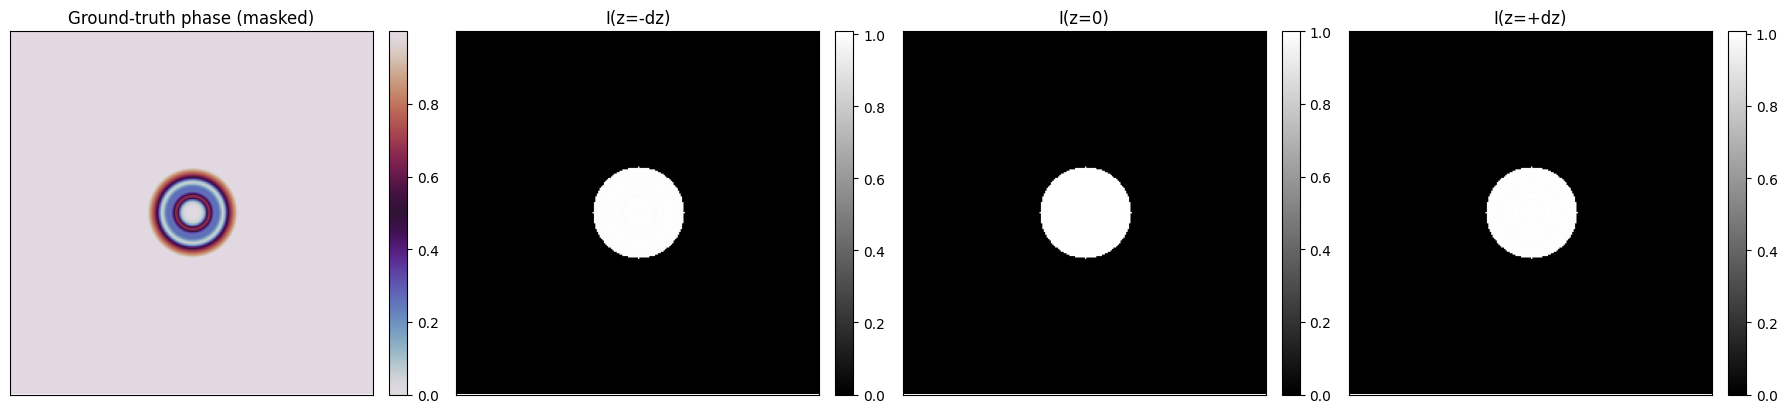

In [ ]:
# Cross-section plot of intensities
fig2, axs2 = plt.subplots(1, 3, figsize=(14, 4))

center = N // 2
x_um = np.asarray((jnp.arange(N) - N // 2) * pixel_size * 1e6)

axs2[0].plot(x_um, np.asarray(I_minus_clean)[center, :], lw=2, color='C0')
axs2[0].set_title("I(z=-dz) cross-section")
axs2[0].set_xlabel("x [µm]")
axs2[0].set_ylabel("Intensity")
axs2[0].grid(True, alpha=0.3)

axs2[1].plot(x_um, np.asarray(I0_clean)[center, :], lw=2, color='C1')
axs2[1].set_title("I(z=0) cross-section")
axs2[1].set_xlabel("x [µm]")
axs2[1].set_ylabel("Intensity")
axs2[1].grid(True, alpha=0.3)

axs2[2].plot(x_um, np.asarray(I_plus_clean)[center, :], lw=2, color='C2')
axs2[2].set_title("I(z=+dz) cross-section")
axs2[2].set_xlabel("x [µm]")
axs2[2].set_ylabel("Intensity")
axs2[2].grid(True, alpha=0.3)

plt.tight_layout()


In [9]:
# -----------------------------
# Reconstruction helper
# -----------------------------
def run_reconstruction(
    I_minus_obs,
    I0_obs,
    I_plus_obs,
    *,
    dz,
    do_opt=True,
    maxfun=300,
    local_refine=True,
    reg_l2=bc_l2,
):
    dI_dz = (I_plus_obs - I_minus_obs) / (2.0 * dz)

    coeff0 = jnp.zeros((n_bc_modes,), dtype=jnp.float64)
    phi_naive = solve_phase_with_bc_coeffs(coeff0, I0_obs, dI_dz, wavelength, pixel_size)

    out = {
        "phi_naive": phi_naive,
        "coeff_naive": np.zeros((n_bc_modes,), dtype=float),
        "opt": None,
    }

    if do_opt:
        obj = make_objective(I_minus_obs, I0_obs, I_plus_obs, lam=wavelength, dz=dz, L=L_window, dx=pixel_size, reg_l2=reg_l2)
        opt_res = optimize_bc_coeffs(obj, n_bc_modes, coeff_bound=bc_coeff_bound, maxfun=maxfun, local_refine=local_refine)
        coeff_best = jnp.asarray(opt_res["best_coeffs"], dtype=jnp.float64)
        phi_opt = solve_phase_with_bc_coeffs(coeff_best, I0_obs, dI_dz, wavelength, pixel_size)

        out["phi_opt"] = phi_opt
        out["coeff_opt"] = coeff_best
        out["opt"] = opt_res
    else:
        out["phi_opt"] = phi_naive
        out["coeff_opt"] = coeff0

    return out


In [10]:
# -----------------------------
# Noiseless baseline + BC ablation
# -----------------------------
res_clean = run_reconstruction(
    I_minus_clean,
    I0_clean,
    I_plus_clean,
    dz=base_dz,
    do_opt=True,
    maxfun=direct_maxfun_main,
    local_refine=run_local_refine,
)

m_naive = summarize_metrics(res_clean["phi_naive"], phi_true, R, ap_mask, gt_params)
m_opt = summarize_metrics(res_clean["phi_opt"], phi_true, R, ap_mask, gt_params)

print("Optimization source:", res_clean["opt"]["best_source"])
print("Best objective:", res_clean["opt"]["best_loss"])

print("\nNaive BC metrics:")
for k in ["rmse", "low_freq_rmse", "a2_rel_err", "ring1_r_rel_err", "ring2_r_rel_err"]:
    print(f"  {k}: {m_naive[k]:.6e}")

print("\nOptimized BC metrics:")
for k in ["rmse", "low_freq_rmse", "a2_rel_err", "ring1_r_rel_err", "ring2_r_rel_err"]:
    print(f"  {k}: {m_opt[k]:.6e}")


Optimization source: DIRECT + L-BFGS-B
Best objective: 7.939142831835765e-08

Naive BC metrics:
  rmse: 5.324413e-03
  low_freq_rmse: 1.266347e-03
  a2_rel_err: 1.000000e+00
  ring1_r_rel_err: 1.641414e-02
  ring2_r_rel_err: 2.332888e-01

Optimized BC metrics:
  rmse: 5.324414e-03
  low_freq_rmse: 1.266420e-03
  a2_rel_err: 1.000000e+00
  ring1_r_rel_err: 1.641414e-02
  ring2_r_rel_err: 2.332888e-01


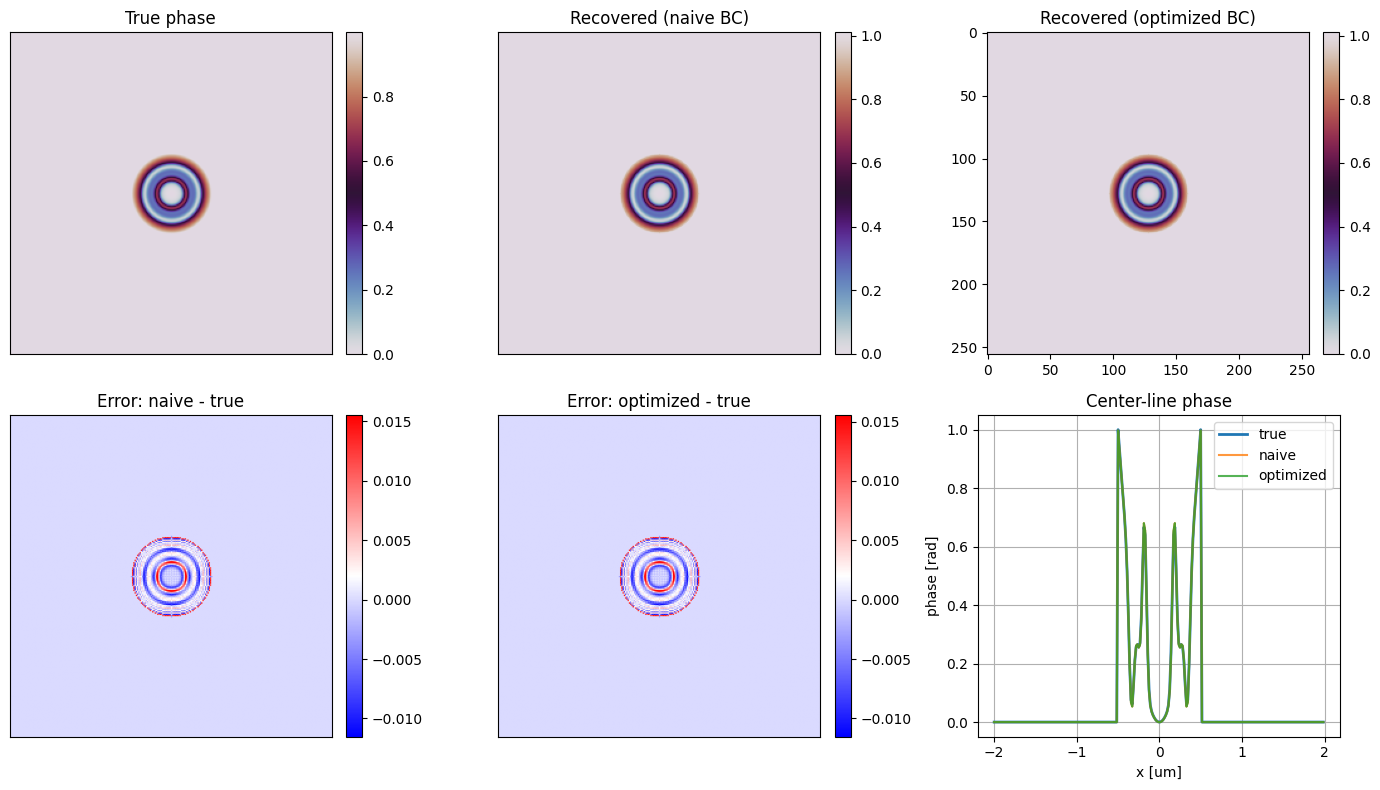

In [11]:
# Visual comparison: true vs naive vs optimized
phi_true_np = np.asarray(phi_true * ap_mask)
phi_naive_np = np.asarray(m_naive["phi_aligned"] * ap_mask)
phi_opt_np = np.asarray(m_opt["phi_aligned"] * ap_mask)

err_naive = phi_naive_np - phi_true_np
err_opt = phi_opt_np - phi_true_np

fig, axs = plt.subplots(2, 3, figsize=(14, 8))

im00 = axs[0, 0].imshow(phi_true_np, cmap="twilight")
axs[0, 0].set_title("True phase")
plt.colorbar(im00, ax=axs[0, 0], fraction=0.046, pad=0.04)

im01 = axs[0, 1].imshow(phi_naive_np, cmap="twilight")
axs[0, 1].set_title("Recovered (naive BC)")
plt.colorbar(im01, ax=axs[0, 1], fraction=0.046, pad=0.04)

im02 = axs[0, 2].imshow(phi_opt_np, cmap="twilight")
axs[0, 2].set_title("Recovered (optimized BC)")
plt.colorbar(im02, ax=axs[0, 2], fraction=0.046, pad=0.04)

im10 = axs[1, 0].imshow(err_naive, cmap="bwr")
axs[1, 0].set_title("Error: naive - true")
plt.colorbar(im10, ax=axs[1, 0], fraction=0.046, pad=0.04)

im11 = axs[1, 1].imshow(err_opt, cmap="bwr")
axs[1, 1].set_title("Error: optimized - true")
plt.colorbar(im11, ax=axs[1, 1], fraction=0.046, pad=0.04)

center = N // 2
x_um = np.asarray((jnp.arange(N) - N // 2) * pixel_size * 1e6)
axs[1, 2].plot(x_um, phi_true_np[center], label="true", lw=2)
axs[1, 2].plot(x_um, phi_naive_np[center], label="naive", alpha=0.8)
axs[1, 2].plot(x_um, phi_opt_np[center], label="optimized", alpha=0.8)
axs[1, 2].set_title("Center-line phase")
axs[1, 2].set_xlabel("x [um]")
axs[1, 2].set_ylabel("phase [rad]")
axs[1, 2].legend()
axs[1, 2].grid(True)

for row in axs:
    for ax in row[:2]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()


In [12]:
# -----------------------------
# Scenario runner for robustness tests
# -----------------------------
def make_nonuniform_amplitude(mask, R, radius):
    taper = 1.0 - 0.35 * (R / radius) ** 2
    taper = jnp.clip(taper, 0.45, 1.0)
    return mask * taper


def run_scenario(
    *,
    dz,
    poisson_counts=None,
    read_noise_sigma=0.0,
    nonuniform_intensity=False,
    maxfun=direct_maxfun_sweep,
):
    amp = ap_mask
    if nonuniform_intensity:
        amp = make_nonuniform_amplitude(ap_mask, R, aperture_radius)

    U0 = amp * jnp.exp(1j * phi_true)

    Im, I0, Ip = simulate_focus_stack(U0, L_window, wavelength, dz)
    Im, I0, Ip = add_noise_stack(Im, I0, Ip, poisson_counts=poisson_counts, read_noise_sigma=read_noise_sigma, key_seed=123)
    Im, I0, Ip = register_stack_identity(Im, I0, Ip)
    Im, I0, Ip = normalize_stack(Im, I0, Ip)

    rec = run_reconstruction(Im, I0, Ip, dz=dz, do_opt=True, maxfun=maxfun, local_refine=run_local_refine)

    met_naive = summarize_metrics(rec["phi_naive"], phi_true, R, ap_mask, gt_params)
    met_opt = summarize_metrics(rec["phi_opt"], phi_true, R, ap_mask, gt_params)

    return {
        "stack": (Im, I0, Ip),
        "recon": rec,
        "naive": met_naive,
        "opt": met_opt,
    }


In [13]:
# -----------------------------
# Test scenarios requested in the plan
# -----------------------------
results = {}

# 1) Noiseless baseline (already run above, keep here for table)
results["noiseless"] = {
    "naive": m_naive,
    "opt": m_opt,
}

# 2) Moderate noise
res_noise = run_scenario(dz=base_dz, poisson_counts=5_000.0, read_noise_sigma=0.01, nonuniform_intensity=False)
results["moderate_noise"] = {
    "naive": res_noise["naive"],
    "opt": res_noise["opt"],
}

# 3) Defocus-step sweep
dz_values = [0.5 * base_dz, base_dz, 1.5 * base_dz]
for dzv in dz_values:
    key = f"dz_{dzv*1e6:.1f}um"
    rr = run_scenario(dz=dzv, poisson_counts=None, read_noise_sigma=0.0, nonuniform_intensity=False)
    results[key] = {
        "naive": rr["naive"],
        "opt": rr["opt"],
    }

# 4) Intensity nonuniformity stress test
res_nonuniform = run_scenario(dz=base_dz, poisson_counts=None, read_noise_sigma=0.0, nonuniform_intensity=True)
results["nonuniform_intensity"] = {
    "naive": res_nonuniform["naive"],
    "opt": res_nonuniform["opt"],
}

print("Completed scenarios:", list(results.keys()))


Completed scenarios: ['noiseless', 'moderate_noise', 'dz_10.0um', 'dz_20.0um', 'dz_30.0um', 'nonuniform_intensity']


In [14]:
# Summary table
rows = []
for name, val in results.items():
    for tag in ["naive", "opt"]:
        m = val[tag]
        rows.append([
            name,
            tag,
            m["rmse"],
            m["low_freq_rmse"],
            m["a2_rel_err"],
            m["ring1_r_rel_err"],
            m["ring2_r_rel_err"],
        ])

header = [
    "scenario",
    "method",
    "phase_rmse",
    "low_freq_rmse",
    "a2_rel_err",
    "ring1_radius_rel_err",
    "ring2_radius_rel_err",
]

print(" | ".join(header))
for r in rows:
    print(f"{r[0]} | {r[1]} | {r[2]:.4e} | {r[3]:.4e} | {r[4]:.4e} | {r[5]:.4e} | {r[6]:.4e}")


scenario | method | phase_rmse | low_freq_rmse | a2_rel_err | ring1_radius_rel_err | ring2_radius_rel_err
noiseless | naive | 5.3244e-03 | 1.2663e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
noiseless | opt | 5.3244e-03 | 1.2664e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
moderate_noise | naive | 3.7743e+00 | 3.5198e+00 | 1.0000e+00 | 2.1465e-02 | 2.3463e-01
moderate_noise | opt | 3.7744e+00 | 3.5200e+00 | 1.0000e+00 | 2.1465e-02 | 2.3463e-01
dz_10.0um | naive | 5.3412e-03 | 1.2672e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
dz_10.0um | opt | 5.3412e-03 | 1.2672e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
dz_20.0um | naive | 5.3244e-03 | 1.2663e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
dz_20.0um | opt | 5.3244e-03 | 1.2664e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
dz_30.0um | naive | 5.2967e-03 | 1.2661e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
dz_30.0um | opt | 5.2966e-03 | 1.2662e-03 | 1.0000e+00 | 1.6414e-02 | 2.3329e-01
nonuniform_intensity | naive | 5.2354e-03 | 1.2822e-03 | 1.0000e

## Acceptance-Criteria Checks

Suggested checks for this notebook run:

1. `optimized BC` should outperform `naive BC` on at least:
   - phase RMSE
   - low-frequency RMSE
2. Noiseless `a2_rel_err` should be small (target: <= 5%).
3. Ring radius relative errors should be in a practical band (target: <= 5-10% noiseless).

If these fail:
- Increase `direct_maxfun_main`.
- Tune `intensity_floor`, `bc_l2`, and `base_dz`.
- Adjust ring amplitudes/sigmas to avoid near-singular data regimes.


## Implementation Notes

- The finite-difference solve uses `A = -div(I grad)` so CG sees a positive-definite operator under Dirichlet boundary conditions.
- Boundary conditions are encoded on the **outer rectangular frame** with 8 Fourier coefficients.
- Re-propagation mismatch at `+/-dz` is used as the optimization objective, matching the paper's variational boundary strategy.
